In [1]:
import os
os.chdir('/home/jupyter/fair')

import pandas as pd
import numpy as np
from IPython.display import Markdown, display, Image
from google.cloud import bigquery
from google.oauth2 import service_account
import fair
from fair.queries.pull_hcb_data_gcp import query_medicaid_gcp

In [2]:
def redact_id(df,col):
    df_temp = df.copy()
    df_temp[col] = '####'
    return df_temp

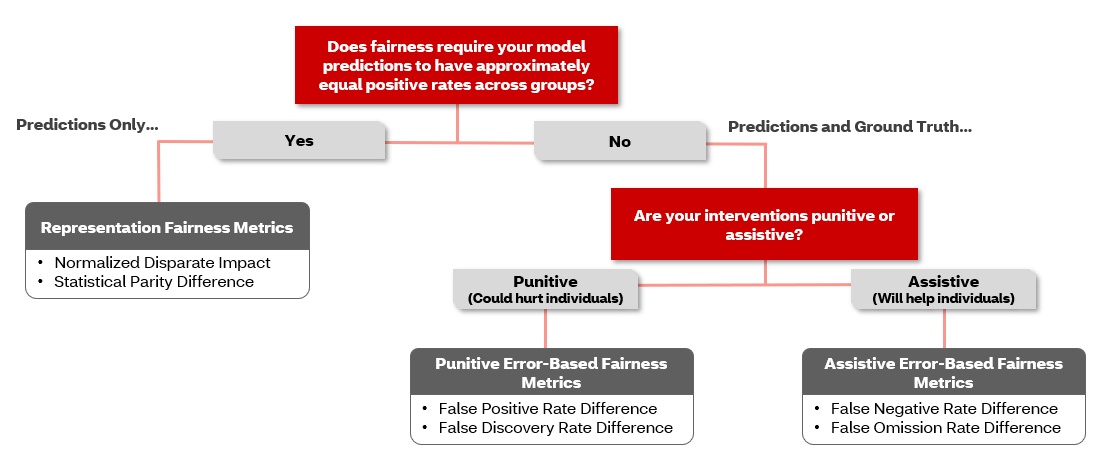

In [3]:
Image(filename='images/fairness_tree.png')

In [4]:
client = bigquery.Client(location="US",project='anbc-hcb-dev')
sql = "SELECT * FROM `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_bias_check`"

query_job = client.query(sql)
df = query_job.result().to_dataframe()

/opt/conda/envs/fair-env/lib/python3.8/site-packages/google_cloud_bigquery-3.25.0-py3.8.egg/google/cloud/bigquery/table.py:2309: UserWarning: Unable to represent RANGE schema as struct using pandas ArrowDtype. Using `object` instead. To use ArrowDtype, use pandas >= 1.5 and pyarrow >= 10.0.1.
  warnings.warn(_RANGE_PYARROW_WARNING)
/opt/conda/envs/fair-env/lib/python3.8/site-packages/google_cloud_bigquery-3.25.0-py3.8.egg/google/cloud/bigquery/table.py:2323: UserWarning: Unable to represent RANGE schema as struct using pandas ArrowDtype. Using `object` instead. To use ArrowDtype, use pandas >= 1.5 and pyarrow >= 10.0.1.
  warnings.warn(_RANGE_PYARROW_WARNING)
/opt/conda/envs/fair-env/lib/python3.8/site-packages/google_cloud_bigquery-3.25.0-py3.8.egg/google/cloud/bigquery/table.py:2337: UserWarning: Unable to represent RANGE schema as struct using pandas ArrowDtype. Using `object` instead. To use ArrowDtype, use pandas >= 1.5 and pyarrow >= 10.0.1.
  warnings.warn(_RANGE_PYARROW_WARNING

In [5]:
df['other_race'] = np.where((df['white'] == 0) & (df['black'] == 0 ), 1, 0)

In [6]:
redact_id(df,'asdb_member_key')

,asdb_member_key,male,female,other_gender,white,black,hispanic,asian,predicted_ip,ground_truth,other_race
0,####,0,1,0,0,0,0,0,0,0,1
1,####,0,1,0,0,0,0,0,0,0,1
2,####,0,1,0,0,0,0,0,0,0,1
3,####,0,1,0,0,0,1,0,0,0,1
4,####,0,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2191614,####,0,1,0,1,0,0,0,0,0,0
2191615,####,0,1,0,1,0,0,0,0,0,0
2191616,####,0,1,0,1,0,0,0,0,0,0
2191617,####,0,1,0,1,0,0,0,0,0,0


### Bias Test Results for `male` Attribute

***

##### Error-Based Fairness Metrics (Assistive)

+-----------------+------------------------------+-----------------------------+
|                 |     False Negative Rate      |     False Omission Rate     |
|                 |          Difference          |         Difference          |
+=================+==============================+=============================+
| Target Value    | 0                            | 0                           |
+-----------------+------------------------------+-----------------------------+
| Bias Threshold  | 0.100                        | 0.100                       |
+-----------------+------------------------------+-----------------------------+
| Metric Value    | 0.006                        | 0.001                       |
+-----------------+------------------------------+-----------------------------+
| Potential Bias? | No                           | No                          |
+-----------------+------------------------------+-----------------------------+
| Favored Group   | N/A - No

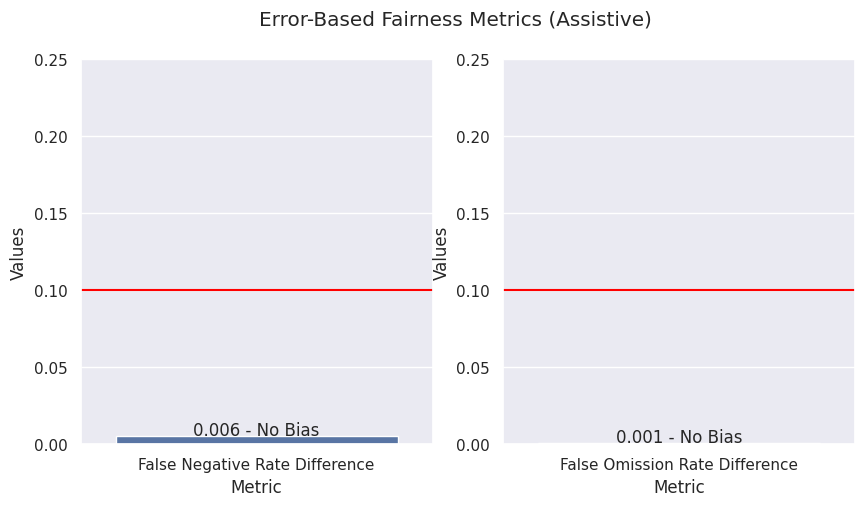

***

#### **Result**: All relevant fairness metrics below bias threshold. No mitigation needed.

***

In [7]:
fair.bias_test(
    df=df[df.other_gender==0],
    priv_col='male',
    pred_col='predicted_ip',
    truth_col='ground_truth'
)

### Bias Test Results for `white` Attribute

***

##### Error-Based Fairness Metrics (Assistive)

+-----------------+------------------------------+-----------------------------+
|                 |     False Negative Rate      |     False Omission Rate     |
|                 |          Difference          |         Difference          |
+=================+==============================+=============================+
| Target Value    | 0                            | 0                           |
+-----------------+------------------------------+-----------------------------+
| Bias Threshold  | 0.100                        | 0.100                       |
+-----------------+------------------------------+-----------------------------+
| Metric Value    | 0.031                        | 0.002                       |
+-----------------+------------------------------+-----------------------------+
| Potential Bias? | No                           | No                          |
+-----------------+------------------------------+-----------------------------+
| Favored Group   | N/A - No

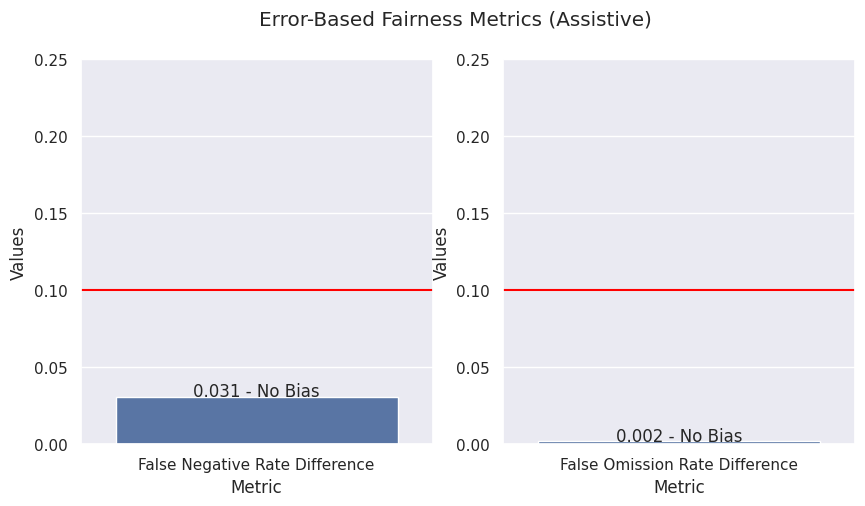

***

#### **Result**: All relevant fairness metrics below bias threshold. No mitigation needed.

***

In [8]:
fair.bias_test(
    df=df[df.other_race==0],
    priv_col='white',
    pred_col='predicted_ip',
    truth_col='ground_truth'
)

In [9]:
df['other_race'] = np.where((df['white'] == 0) & (df['hispanic'] == 0 ), 1, 0)

### Bias Test Results for `white` Attribute

***

##### Error-Based Fairness Metrics (Assistive)

+-----------------+------------------------------+-----------------------------+
|                 |     False Negative Rate      |     False Omission Rate     |
|                 |          Difference          |         Difference          |
+=================+==============================+=============================+
| Target Value    | 0                            | 0                           |
+-----------------+------------------------------+-----------------------------+
| Bias Threshold  | 0.100                        | 0.100                       |
+-----------------+------------------------------+-----------------------------+
| Metric Value    | 0.015                        | 0.005                       |
+-----------------+------------------------------+-----------------------------+
| Potential Bias? | No                           | No                          |
+-----------------+------------------------------+-----------------------------+
| Favored Group   | N/A - No

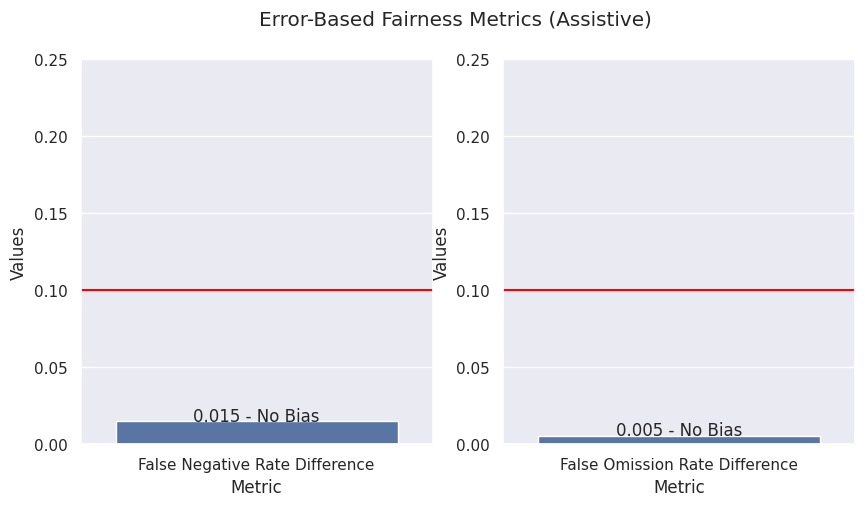

***

#### **Result**: All relevant fairness metrics below bias threshold. No mitigation needed.

***

In [10]:
fair.bias_test(
    df=df[df.other_race==0],
    priv_col='white',
    pred_col='predicted_ip',
    truth_col='ground_truth'
)

In [11]:
df['other_race'] = np.where((df['white'] == 0) & (df['asian'] == 0 ), 1, 0)

### Bias Test Results for `white` Attribute

***

##### Error-Based Fairness Metrics (Assistive)

+-----------------+------------------------------+-----------------------------+
|                 |     False Negative Rate      |     False Omission Rate     |
|                 |          Difference          |         Difference          |
+=================+==============================+=============================+
| Target Value    | 0                            | 0                           |
+-----------------+------------------------------+-----------------------------+
| Bias Threshold  | 0.100                        | 0.100                       |
+-----------------+------------------------------+-----------------------------+
| Metric Value    | 0.034                        | 0.005                       |
+-----------------+------------------------------+-----------------------------+
| Potential Bias? | No                           | No                          |
+-----------------+------------------------------+-----------------------------+
| Favored Group   | N/A - No

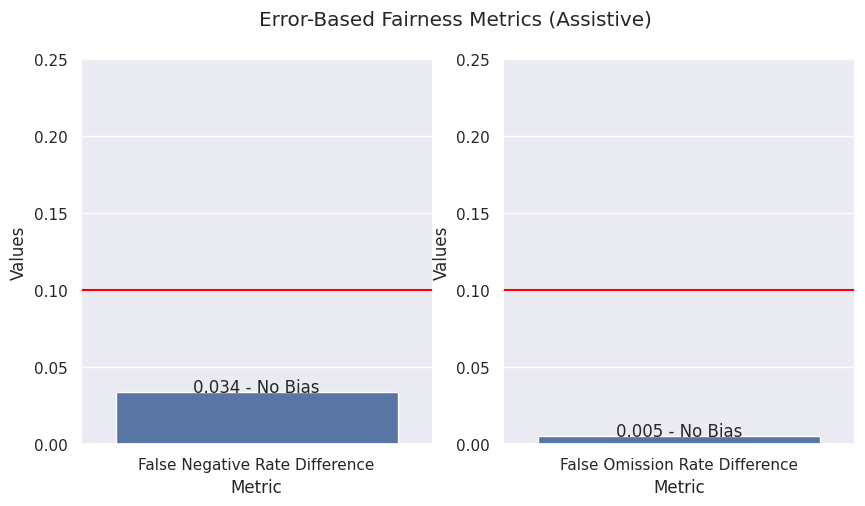

***

#### **Result**: All relevant fairness metrics below bias threshold. No mitigation needed.

***

In [12]:
fair.bias_test(
    df=df[df.other_race==0],
    priv_col='white',
    pred_col='predicted_ip',
    truth_col='ground_truth'
)